### Exploração dos dados obtidos

Este notebook serve para a exploração da rede e sua compreensão.
Ele não tema  função de gerar nenhum output para o projeto.

In [19]:
import sys
from pathlib import Path

# adiciona a raiz do projeto ao Python
sys.path.append(str(Path.cwd().parent))

In [20]:
# Bibliotecas
import osmnx as ox
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import importlib
import json

In [21]:
# Importa metodos
import src.classification as classification
import src.visualization as visualization

In [22]:
# Recarrega biblioteca para pegar as alterações recentes
importlib.reload(classification)
importlib.reload(visualization)

<module 'src.visualization' from 'c:\\Users\\Simone\\Documents\\GitHub\\EtPilot\\src\\visualization.py'>

In [23]:

# Carrega o grafo da rede de ruas do bairro desejado
graph = ox.load_graphml("../data/graph/rede-bomFim.graphml")

# Converte para GeoDataFrames
gdf_nodes, gdf_edges = ox.graph_to_gdfs(graph)

In [24]:
# Exploração
gdf_edges.columns
gdf_edges["highway"].value_counts()

highway
tertiary          29
primary           17
secondary         15
busway            14
residential       13
secondary_link     2
Name: count, dtype: int64

In [25]:
len(gdf_edges)

90

In [27]:
gdf_edges = classification.classify_network(
    gdf_edges,
    road_classification["en"]
)

Classificação de vias

| Tipo             | Significado                  | Modal predominante|
| ---------------- | ---------------------------- | ----------------- |
| `primary`        | Via arterial principal       | Carro / ônibus    |
| `secondary`      | Via coletora importante      | Carro / ônibus    |
| `secondary_link` | Alça de ligação              | Carro             |
| `tertiary`       | Via coletora local           | Carro             |
| `residential`    | Rua residencial              | Carro / pedestre  |
| `busway`         | Corredor exclusivo de ônibus | Ônibus            |

Obs: 
Não apareceu `cycleway`

Possibilidades:
- Não existem ciclovias na área escolhida;
- Existem, mas baixou apenas a rede "drive";
- As ciclovias estão mapeadas de outra forma no OpenStreetMap.

In [28]:
with open("../config/road_classification.json", "r", encoding="utf-8") as f:
    road_classification = json.load(f)

mapping = road_classification["en"]

gdf_edges = classification.classify_network(
    gdf_edges,
    mapping
    #road_classification["en"]
)

gdf_edges["road_type"].value_counts()


road_type
Local Collector       29
Arterial Road         17
Collector Road        15
Bus Corridor          14
Residential Street    13
Other                  2
Name: count, dtype: int64

(<Figure size 1200x1200 with 1 Axes>, <Axes: >)

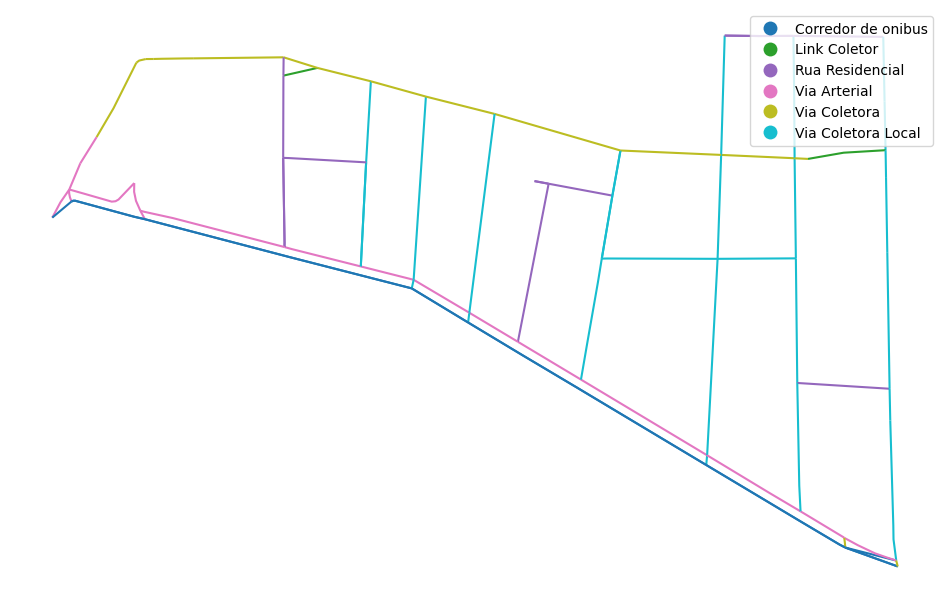

In [14]:
# Plota a rede com as vias classificadas
visualization.plot_network(
    gdf_edges,
    column="road_type"
)

In [15]:
# Classifica a rede por modal
gdf_edges["modal"] = gdf_edges.apply(
    classification.classify_modal,
    axis=1
)

modal_por_rua = (
    gdf_edges
    .groupby("name")["modal"]
    .unique()
)

In [16]:
gdf_edges[["name", "highway", "road_type"]].head(20)

gdf_edges["road_type"].value_counts()

gdf_edges[
    gdf_edges["name"].str.contains(
        "Osvaldo Aranha",
        case=False,
        na=False
    )
][["name", "highway", "road_type"]]

,,,name,highway,road_type
u,v,key,,,
295523329,842729634,0,Avenida Osvaldo Aranha,primary,Via Arterial
295523686,295523692,0,Avenida Osvaldo Aranha,primary,Via Arterial
295523692,295523695,0,Avenida Osvaldo Aranha,primary,Via Arterial
295523695,295523697,0,Avenida Osvaldo Aranha,primary,Via Arterial
295523697,295523700,0,Avenida Osvaldo Aranha,primary,Via Arterial
295523700,297623758,0,Avenida Osvaldo Aranha,primary,Via Arterial
297623758,483851076,0,Avenida Osvaldo Aranha,primary,Via Arterial
483851076,295523710,0,Avenida Osvaldo Aranha,primary,Via Arterial
842729634,295523686,0,Avenida Osvaldo Aranha,primary,Via Arterial


<Axes: >

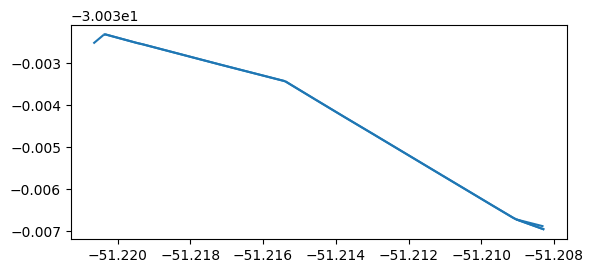

In [17]:
gdf_edges[gdf_edges["road_type"]=="Corredor de onibus"].plot()

In [18]:
ruas = (
    gdf_edges
    .groupby("name")
    .agg({
        "road_type": lambda x: list(x.unique())
    })
)
ruas.all

<bound method DataFrame.all of                                                                          road_type
name                                                                              
Avenida Cauduro                                                  [Rua Residencial]
Avenida Osvaldo Aranha                                              [Via Arterial]
Avenida Setembrina                                            [Via Coletora Local]
Avenida Venâncio Aires                                              [Via Coletora]
Corredor de Transporte Coletivo Osvaldo Aranha                [Corredor de onibus]
Rua Antão de Faria                                               [Rua Residencial]
Rua Bento Figueiredo                                             [Rua Residencial]
Rua Castro Alves                                                 [Rua Residencial]
Rua Doutor Barros Cassal                                         [Rua Residencial]
Rua Felipe Camarão                                      

In [19]:
# Problema: o grafo representa a Av. Osvaldo Aranha como duas arestas diferentes, uma para o corredor de onibus e outra para a via de carros. 
# para resolver isso (temporariamente), estarei renomeando o corredor de onibus para "Avenida Osvaldo Aranha".
gdf_edges.loc[
    gdf_edges["name"].str.contains("Osvaldo Aranha", case=False, na=False),
    "name"
] = "Avenida Osvaldo Aranha"